In [2]:
# Import required libraries
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

In [3]:
# Initialize PySpark session
spark = SparkSession.builder.appName("Telco Churn Analysis").getOrCreate()

In [4]:
# Load dataset
file_path = "/content/Telco_Customer_Churn.csv"
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

In [5]:
# Convert PySpark DataFrame to Pandas for visualization
df = df_spark.toPandas()
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7129-CAKJW,Female,0,No,No,17,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Bank transfer (automatic),80.05,1345.65,No
1,9802-CAQUT,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,Yes,Two year,No,Credit card (automatic),109.55,7887.25,No
2,4803-LBYPN,Male,0,Yes,Yes,34,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.80,635.9,No
3,0716-BQNDX,Male,1,No,No,57,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,Yes,Two year,No,Electronic check,93.75,5625.55,No
4,2379-GYFLQ,Male,0,No,No,46,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),94.90,4422.95,No


In [6]:
# Data Cleaning & Preprocessing
# Convert categorical columns to numeric using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [7]:
# Handling missing values
df.fillna(df.mean(), inplace=True)


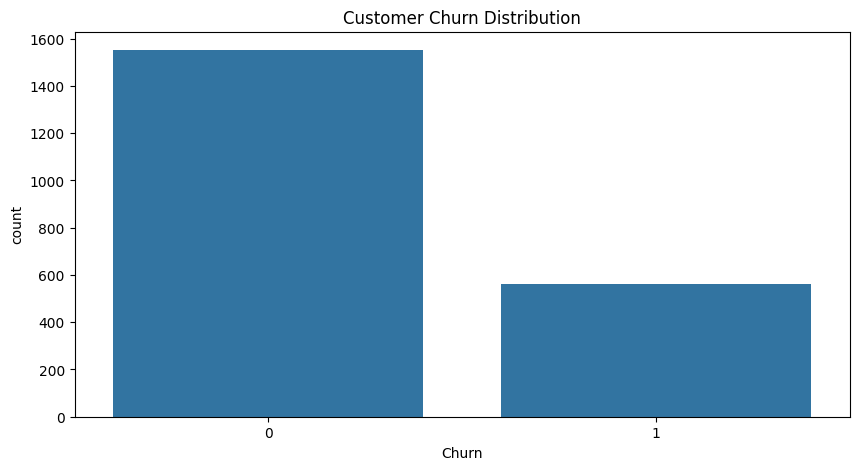

In [8]:
# Data Visualization
plt.figure(figsize=(10,5))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

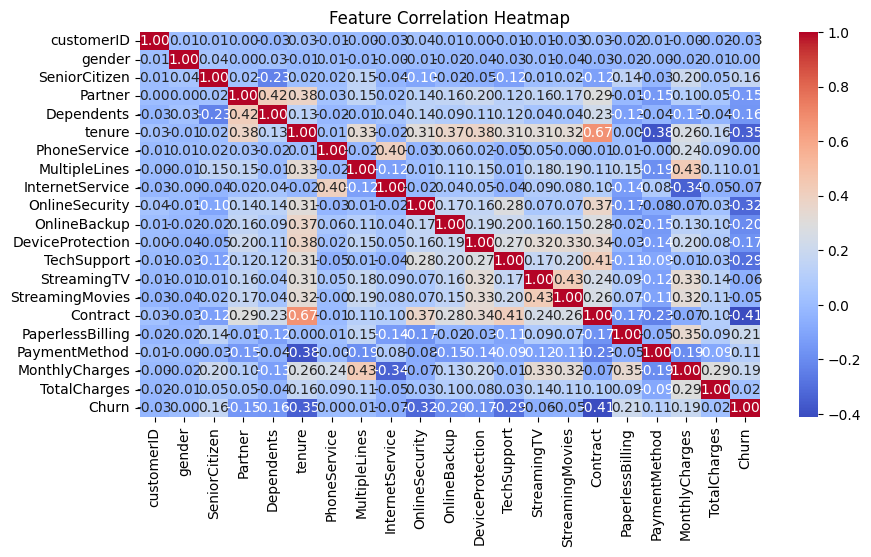

In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [10]:
# Feature Selection
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Standardizing data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Machine Learning Models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

accuracies = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[name] = accuracy
    print(f'{name} Accuracy: {accuracy:.4f}')
    print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.7589
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       293
           1       0.68      0.42      0.51       130

    accuracy                           0.76       423
   macro avg       0.73      0.66      0.68       423
weighted avg       0.75      0.76      0.74       423

Gradient Boosting Accuracy: 0.7754
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       293
           1       0.69      0.49      0.57       130

    accuracy                           0.78       423
   macro avg       0.74      0.70      0.71       423
weighted avg       0.77      0.78      0.76       423

Support Vector Machine Accuracy: 0.7730
              precision    recall  f1-score   support

           0       0.80      0.89      0.85       293
           1       0.68      0.50      0.58       130

    accuracy                           0.77       423
   macro avg       0.7

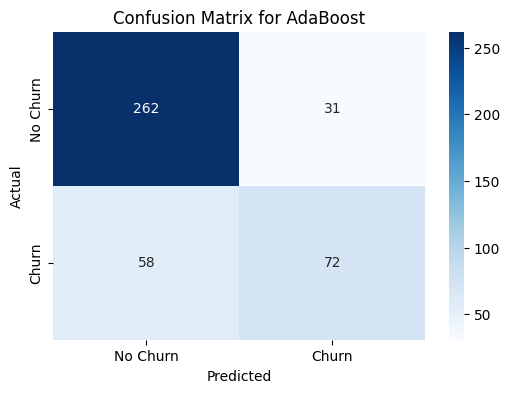

In [14]:
 # Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for {name}')
plt.show()

<ipython-input-15-517190b40879>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


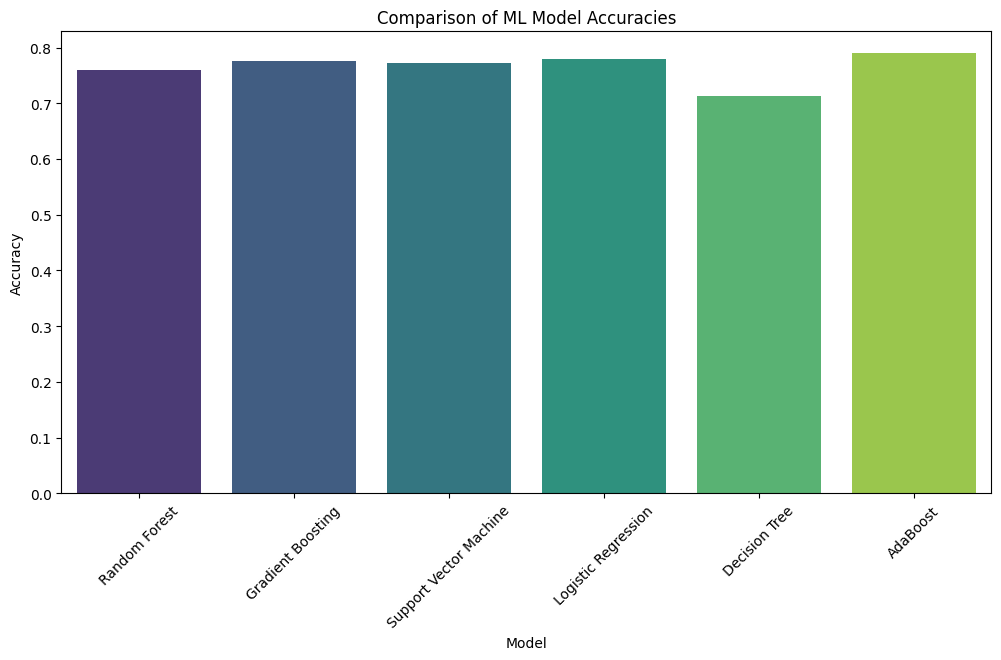

In [15]:
# Accuracy Comparison Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of ML Model Accuracies')
plt.xticks(rotation=45)
plt.show()


In [16]:
# PyTorch Model
class ChurnModel(nn.Module):
    def __init__(self, input_dim):
        super(ChurnModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x


In [17]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [18]:
# Initialize model, loss function, and optimizer
model = ChurnModel(X_train.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [19]:
# Train the PyTorch model
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.6837426424026489
Epoch 10, Loss: 0.4305388927459717
Epoch 20, Loss: 0.39674362540245056
Epoch 30, Loss: 0.3605457544326782
Epoch 40, Loss: 0.33308419585227966
Epoch 50, Loss: 0.2997434735298157
Epoch 60, Loss: 0.2605738341808319
Epoch 70, Loss: 0.21383430063724518
Epoch 80, Loss: 0.17353713512420654
Epoch 90, Loss: 0.13684840500354767


In [20]:
# TensorFlow & Keras Model
model_keras = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Compile the model
model_keras.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [22]:
# Train the model
model_keras.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))

print("Training complete!")

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5411 - loss: 0.6867 - val_accuracy: 0.7187 - val_loss: 0.5187
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7952 - loss: 0.4425 - val_accuracy: 0.7423 - val_loss: 0.4815
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8049 - loss: 0.4224 - val_accuracy: 0.7636 - val_loss: 0.4726
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8104 - loss: 0.4076 - val_accuracy: 0.7565 - val_loss: 0.4667
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8146 - loss: 0.3946 - val_accuracy: 0.7541 - val_loss: 0.4731
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8408 - loss: 0.3606 - val_accuracy: 0.7660 - val_loss: 0.4634
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8413 - loss: 0.3584 - val_accuracy: 0.7660 - val_loss: 0.4645
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8364 - loss: 0.3570 - val_accuracy: 0.7683 - val_loss: